In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/iamsouravbanerjee/house-rent-prediction-dataset/Dataset Glossary.txt
/kaggle/input/datasets/iamsouravbanerjee/house-rent-prediction-dataset/House_Rent_Dataset.csv


In [2]:
#what effect rain ,can we predict rent
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("/kaggle/input/datasets/iamsouravbanerjee/house-rent-prediction-dataset/House_Rent_Dataset.csv")
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [3]:

df.shape
df.columns


Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

In [4]:
df.groupby('City')['Rent'].mean().sort_values(ascending=False)

City
Mumbai       85321.204733
Delhi        29461.983471
Bangalore    24966.365688
Chennai      21614.092031
Hyderabad    20555.048387
Kolkata      11645.173664
Name: Rent, dtype: float64

<Axes: xlabel='City'>

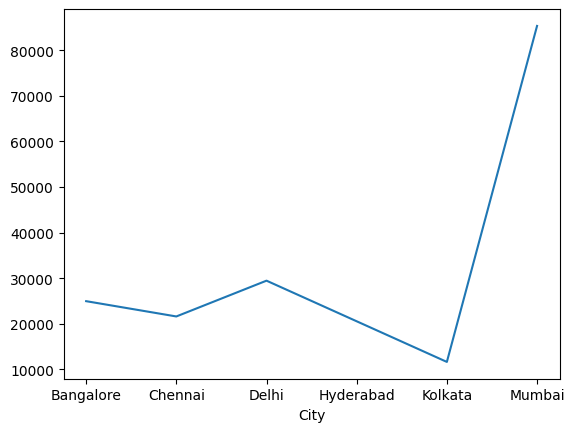

In [5]:

df.groupby('City')['Rent'].mean().plot()




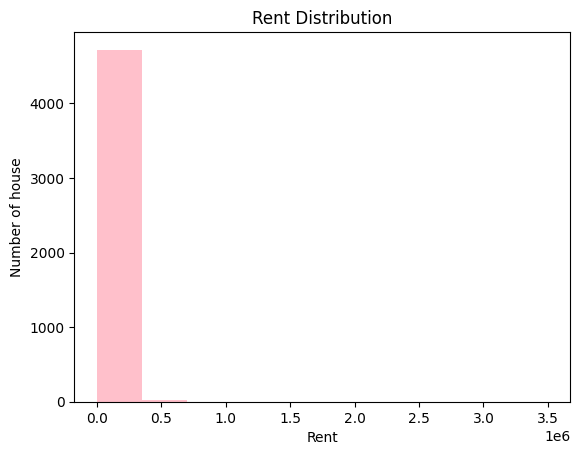

In [6]:
df['Rent'].plot(kind='hist',bins=10,color='Pink')
plt.xlabel('Rent')
plt.ylabel('Number of house')
plt.title('Rent Distribution')
plt.show()

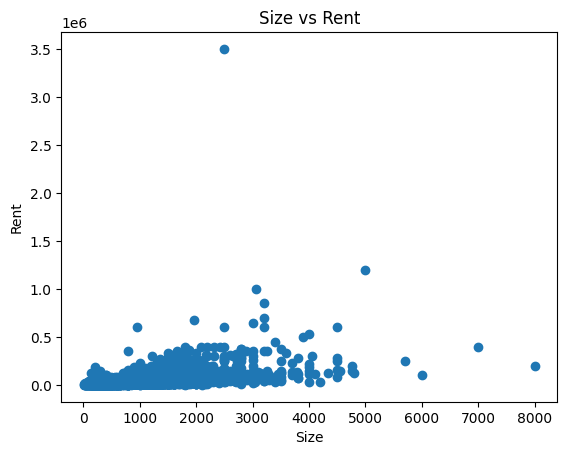

In [7]:
plt.scatter(df['Size'],df['Rent'])
plt.xlabel('Size')
plt.ylabel('Rent')
plt.title('Size vs Rent')
plt.show()

In [8]:
df[['Size','Rent']].corr()

,Size,Rent
Size,1.000000,0.413551
Rent,0.413551,1.000000


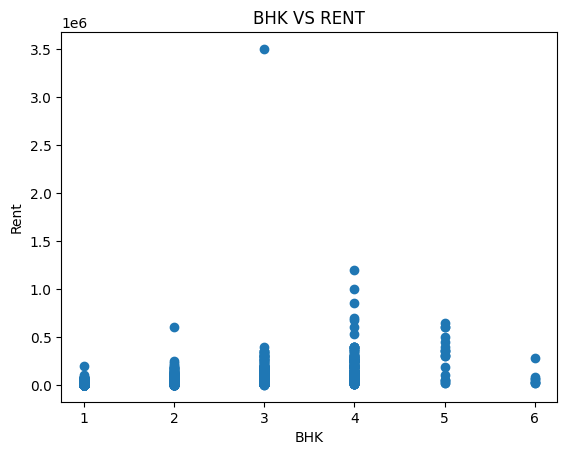

In [9]:
plt.scatter(df['BHK'],df['Rent'])
plt.xlabel('BHK')
plt.ylabel('Rent')

plt.title('BHK VS RENT')
plt.show()

In [10]:
df['rent_per_sqft']=df['Size']/df['Rent']
df['rent_per_sqft']

0       0.110000
1       0.040000
2       0.058824
3       0.080000
4       0.113333
          ...   
4741    0.066667
4742    0.068966
4743    0.050000
4744    0.033333
4745    0.066667
Name: rent_per_sqft, Length: 4746, dtype: float64

In [11]:
X = df.drop('Rent', axis=1)
y = df['Rent']